# Diagnosis — Pre-Experiment Validation of All Methods

This notebook tests every component of the Chapter 3 experiment pipeline before
committing to the full ~30 hour experiment run. Each section validates a specific
method, checks output structure, verifies numerical correctness against known
values, and logs pass/fail results to `diagnosis.log`.

**Run this notebook end-to-end before `ch3_analysis.ipynb`.** If any test fails,
the issue must be resolved before the full experiment.

### Test Coverage

| # | Component | What is checked |
|---|-----------|----------------|
| 1 | Setup & compilation | C++ kernel compiles, all R sources load |
| 2 | C++ kernel — ER | Output structure, compartment ranges, time grid |
| 3 | C++ kernel — BA | BA generation works, output valid |
| 4 | C++ kernel — WS | WS generation works, output valid |
| 5 | Demographic consistency | N = S+E+I+T+R holds at every timestep |
| 6 | Control application | u1 > 0 shifts I to T faster than u1 = 0 |
| 7 | Replicate variability | Multiple replicates produce different trajectories |
| 8 | ODE solver | Converges in known iteration count, J matches Ch.2 |
| 9 | Simpson's rule | Exact on polynomial test case |
| 10 | expand_u1 | Correct length, clipping, segment structure |
| 11 | Network metrics | C, L, sigma, Q, degree stats for each topology |
| 12 | Metric reproducibility | Repeated calls produce consistent means |
| 13 | Control shape descriptors | Known profile produces expected values |
| 14 | Optimisation pipeline | Short 2-start optimisation converges |
| 15 | Forward vs. no-control | Controlled J < uncontrolled J |
| 16 | ODE warm-start | Segment extraction produces valid guess |
| 17 | Parallel cluster | Cluster starts, evaluates, stops cleanly |
| 18 | File I/O | RDS and CSV save/load roundtrip |
| 19 | Plotting | All plot functions execute without error |
| 20 | Size scaling | n=50 and n=200 simulations run correctly |
| 21 | Edge cases | Zero control, max control, K=1, K=t_max |
| 22 | Summary | Final pass/fail count |

# 1 — Setup, Compilation & Logging

In [1]:
# ============================================================================
# SETUP
# ============================================================================
n_pass <- 0L; n_fail <- 0L; n_warn <- 0L
diag_log <- character(0)
dlog <- function(...) {
  ts <- format(Sys.time(), '[%H:%M:%S]')
  msg <- paste0(ts, ' ', paste0(..., collapse = ''))
  diag_log <<- c(diag_log, msg); cat(msg, '\n')
}
dsection <- function(title) {
  bar <- strrep('=', 70)
  blk <- sprintf('\n%s\n  %s\n%s', bar, title, bar)
  diag_log <<- c(diag_log, blk); cat(blk, '\n')
}
PASS <- function(test_name, detail = '') {
  n_pass <<- n_pass + 1L
  msg <- paste0('  PASS: ', test_name, if(nchar(detail)>0) paste0(' -- ',detail) else '')
  diag_log <<- c(diag_log, msg); cat(msg, '\n')
}
FAIL <- function(test_name, detail = '') {
  n_fail <<- n_fail + 1L
  msg <- paste0('  ** FAIL **: ', test_name, if(nchar(detail)>0) paste0(' -- ',detail) else '')
  diag_log <<- c(diag_log, msg); cat(msg, '\n')
}
WARN <- function(test_name, detail = '') {
  n_warn <<- n_warn + 1L
  msg <- paste0('  WARN: ', test_name, if(nchar(detail)>0) paste0(' -- ',detail) else '')
  diag_log <<- c(diag_log, msg); cat(msg, '\n')
}
flush_diag <- function() writeLines(diag_log, 'diagnosis.log')

dsection('DIAGNOSIS SESSION START')
dlog('R version: ', R.version.string)
dlog('Working directory: ', getwd())

dsection('TEST 1: COMPILATION & SOURCE LOADING')
tryCatch({ library(Rcpp); library(ggplot2); library(gridExtra)
  library(parallel); library(optimParallel); library(igraph)
  PASS('Package loading')
}, error = function(e) FAIL('Package loading', e$message))

tryCatch({ Rcpp::sourceCpp('src/seitr_kernel.cpp'); PASS('C++ kernel compilation')
}, error = function(e) FAIL('C++ kernel compilation', e$message))

src_files <- c('src/utils.R','src/ode_control.R','src/experiment.R',
               'src/plotting.R','src/network_metrics.R')
for (f in src_files) {
  tryCatch({ source(f); PASS(paste('Source', f)) },
           error = function(e) FAIL(paste('Source', f), e$message))
}

expected_fns <- c('run_seitr_simulation_cpp', 'calculate_objective_functional',
  'expand_u1', 'get_ode_initial_guess', 'solve_ode_optimal_control',
  'run_experiment', 'plot_ode_results', 'plot_experiment_diagnostics',
  'compute_topology_metrics', 'compute_avg_topology_metrics',
  'compute_control_shape', 'generate_igraph_network')
for (fn in expected_fns) {
  if (exists(fn, mode='function')) PASS(paste('Function exists:', fn))
  if (!exists(fn, mode='function')) FAIL(paste('Function exists:', fn), 'not found')
}
options(repr.plot.width = 8, repr.plot.height = 4)
flush_diag()


  DIAGNOSIS SESSION START
[04:42:33] R version: R version 4.3.1 (2023-06-16) 
[04:42:33] Working directory: /Users/slm/GitHub/SEITRNet++ 

  TEST 1: COMPILATION & SOURCE LOADING


Warning message:
“package ‘Rcpp’ was built under R version 4.3.3”
Warning message:
“package ‘ggplot2’ was built under R version 4.3.3”
Warning message:
“package ‘gridExtra’ was built under R version 4.3.3”
Warning message:
“package ‘optimParallel’ was built under R version 4.3.3”
Warning message:
“package ‘igraph’ was built under R version 4.3.3”

Attaching package: ‘igraph’


The following objects are masked from ‘package:stats’:

    decompose, spectrum


The following object is masked from ‘package:base’:

    union




  PASS: Package loading 
  PASS: C++ kernel compilation 
  PASS: Source src/utils.R 
  PASS: Source src/ode_control.R 
  PASS: Source src/experiment.R 
  PASS: Source src/plotting.R 
  PASS: Source src/network_metrics.R 
  PASS: Function exists: run_seitr_simulation_cpp 
  PASS: Function exists: calculate_objective_functional 
  PASS: Function exists: expand_u1 
  PASS: Function exists: get_ode_initial_guess 
  PASS: Function exists: solve_ode_optimal_control 
  PASS: Function exists: run_experiment 
  PASS: Function exists: plot_ode_results 
  PASS: Function exists: plot_experiment_diagnostics 
  PASS: Function exists: compute_topology_metrics 
  PASS: Function exists: compute_avg_topology_metrics 
  PASS: Function exists: compute_control_shape 
  PASS: Function exists: generate_igraph_network 


# 2-4 — C++ Kernel: ER, BA, WS Simulation

In [2]:
# ============================================================================
# TESTS 2-4: C++ KERNEL — ER, BA, WS
# ============================================================================
dsection('TESTS 2-4: C++ KERNEL')
Lambda <- 0.4; beta1 <- 0.9; beta2 <- 0.059; beta3 <- 0.2
alpha1 <- 0.03; alpha2 <- 0.055; delta_I <- 0.03; delta_T <- 0.03; mu <- 0.02
w1 <- 0.2; zeta <- 1; t_max <- 100; dt <- 1; n <- 100
init_S <- 50; init_E <- 25; init_I <- 15; init_T <- 5; init_R <- 5
u1_test <- rep(0.03, t_max + 1)
total_steps <- length(seq(0, t_max, by = dt))

net_configs <- list(
  list(type='ER', par1=0.5, par2=10L, label='ER'),
  list(type='BA', par1=0.05, par2=10L, label='BA'),
  list(type='WS', par1=0.3, par2=4L, label='WS')
)
sim_results <- list()

for (nc in net_configs) {
  dlog('Testing ', nc$label, '...')
  res <- tryCatch(
    run_seitr_simulation_cpp(nc$type, n, nc$par1, nc$par2,
      Lambda, beta1, beta2, beta3, alpha1, alpha2, delta_I, delta_T, mu,
      init_S, init_E, init_I, init_T, init_R, t_max, u1_test, 5L, w1),
    error = function(e) { FAIL(paste(nc$label, 'simulation'), e$message); NULL }
  )
  if (is.null(res)) next
  sim_results[[nc$label]] <- res

  ok_struct <- all(c('avg','min','max','all') %in% names(res))
  if (ok_struct) PASS(paste(nc$label, 'output structure'))
  if (!ok_struct) FAIL(paste(nc$label, 'output structure'))

  ok_cols <- all(c('time','S','E','I','T','R','N','control_cost') %in% names(res$avg))
  if (ok_cols) PASS(paste(nc$label, 'column names'))
  if (!ok_cols) FAIL(paste(nc$label, 'column names'))

  ok_rows <- nrow(res$avg) == t_max + 2
  if (ok_rows) PASS(paste(nc$label, 'row count'), as.character(nrow(res$avg)))
  if (!ok_rows) FAIL(paste(nc$label, 'row count'), paste('expected', t_max+2, 'got', nrow(res$avg)))

  ok_t0 <- res$avg$time[1] == 0
  if (ok_t0) PASS(paste(nc$label, 'time starts at 0'))
  if (!ok_t0) FAIL(paste(nc$label, 'time starts at 0'))

  comps <- c('S','E','I','T','R','N')
  ok_nn <- all(sapply(comps, function(cc) all(res$avg[[cc]] >= -0.01)))
  if (ok_nn) PASS(paste(nc$label, 'compartments non-negative'))
  if (!ok_nn) FAIL(paste(nc$label, 'compartments non-negative'))

  ok_ic <- abs(res$avg$S[1]-init_S)<1 && abs(res$avg$E[1]-init_E)<1 && abs(res$avg$I[1]-init_I)<1
  if (ok_ic) PASS(paste(nc$label, 'initial conditions'))
  if (!ok_ic) FAIL(paste(nc$label, 'initial conditions'),
    sprintf('S=%.1f E=%.1f I=%.1f', res$avg$S[1], res$avg$E[1], res$avg$I[1]))

  ok_nrep <- length(res$all) == 5
  if (ok_nrep) PASS(paste(nc$label, 'replicate count'))
  if (!ok_nrep) FAIL(paste(nc$label, 'replicate count'), paste('got', length(res$all)))

  ok_order <- all(res$min$I <= res$avg$I + 0.01) && all(res$avg$I <= res$max$I + 0.01)
  if (ok_order) PASS(paste(nc$label, 'min <= avg <= max'))
  if (!ok_order) FAIL(paste(nc$label, 'min <= avg <= max'))

  dlog(sprintf('  Final S=%.1f E=%.1f I=%.1f T=%.1f R=%.1f N=%.1f',
    tail(res$avg$S,1), tail(res$avg$E,1), tail(res$avg$I,1),
    tail(res$avg$T,1), tail(res$avg$R,1), tail(res$avg$N,1)))
}
flush_diag()


  TESTS 2-4: C++ KERNEL
[04:42:34] Testing ER... 
  PASS: ER output structure 
  PASS: ER column names 
  PASS: ER row count -- 102 
  PASS: ER time starts at 0 
  PASS: ER compartments non-negative 
  PASS: ER initial conditions 
  PASS: ER replicate count 
  PASS: ER min <= avg <= max 
[04:42:34]   Final S=15.2 E=1.0 I=0.4 T=0.2 R=10.0 N=26.8 
[04:42:34] Testing BA... 
  PASS: BA output structure 
  PASS: BA column names 
  PASS: BA row count -- 102 
  PASS: BA time starts at 0 
  PASS: BA compartments non-negative 
  PASS: BA initial conditions 
  PASS: BA replicate count 
  PASS: BA min <= avg <= max 
[04:42:34]   Final S=24.0 E=0.0 I=0.0 T=0.0 R=4.2 N=28.2 
[04:42:34] Testing WS... 
  PASS: WS output structure 
  PASS: WS column names 
  PASS: WS row count -- 102 
  PASS: WS time starts at 0 
  PASS: WS compartments non-negative 
  PASS: WS initial conditions 
  PASS: WS replicate count 
  PASS: WS min <= avg <= max 
[04:42:34]   Final S=24.4 E=0.0 I=0.0 T=0.0 R=6.4 N=30.8 


# 5 — Demographic Consistency: N = S+E+I+T+R

In [3]:
dsection('TEST 5: DEMOGRAPHIC CONSISTENCY')
for (nm in names(sim_results)) {
  res <- sim_results[[nm]]
  computed_N <- res$avg$S + res$avg$E + res$avg$I + res$avg$T + res$avg$R
  max_err <- max(abs(computed_N - res$avg$N))
  if (max_err < 0.5) PASS(paste(nm, 'N=S+E+I+T+R'), sprintf('max_err=%.4f', max_err))
  if (max_err >= 0.5) FAIL(paste(nm, 'N=S+E+I+T+R'), sprintf('max_err=%.4f', max_err))
}
flush_diag()


  TEST 5: DEMOGRAPHIC CONSISTENCY
  PASS: ER N=S+E+I+T+R -- max_err=0.0000 
  PASS: BA N=S+E+I+T+R -- max_err=0.0000 
  PASS: WS N=S+E+I+T+R -- max_err=0.0000 


# 6 — Control Application: u1 > 0 Should Increase Treatment

In [4]:
dsection('TEST 6: CONTROL APPLICATION')
u1_strong <- rep(0.5, total_steps)
u1_zero   <- rep(0,   total_steps)
for (nc in net_configs[1:2]) {
  res_ctrl <- run_seitr_simulation_cpp(nc$type, n, nc$par1, nc$par2,
    Lambda, beta1, beta2, beta3, alpha1, alpha2, delta_I, delta_T, mu,
    init_S, init_E, init_I, init_T, init_R, t_max, u1_strong, 10L, w1)
  res_none <- run_seitr_simulation_cpp(nc$type, n, nc$par1, nc$par2,
    Lambda, beta1, beta2, beta3, alpha1, alpha2, delta_I, delta_T, mu,
    init_S, init_E, init_I, init_T, init_R, t_max, u1_zero, 10L, w1)

  peak_T_ctrl <- max(res_ctrl$avg$T); peak_T_none <- max(res_none$avg$T)
  peak_I_ctrl <- max(res_ctrl$avg$I); peak_I_none <- max(res_none$avg$I)

  if (peak_T_ctrl > peak_T_none) PASS(paste(nc$label, 'control increases T'), sprintf('%.1f > %.1f', peak_T_ctrl, peak_T_none))
  if (peak_T_ctrl <= peak_T_none) WARN(paste(nc$label, 'control increases T'), sprintf('%.1f vs %.1f', peak_T_ctrl, peak_T_none))

  if (peak_I_ctrl < peak_I_none) PASS(paste(nc$label, 'control reduces I'), sprintf('%.1f < %.1f', peak_I_ctrl, peak_I_none))
  if (peak_I_ctrl >= peak_I_none) WARN(paste(nc$label, 'control reduces I'), sprintf('%.1f vs %.1f (stochastic)', peak_I_ctrl, peak_I_none))

  cc_ctrl <- sum(res_ctrl$avg$control_cost); cc_none <- sum(res_none$avg$control_cost)
  if (cc_ctrl > cc_none && cc_none < 0.01) PASS(paste(nc$label, 'control cost correct'), sprintf('%.2f vs %.4f', cc_ctrl, cc_none))
  if (!(cc_ctrl > cc_none && cc_none < 0.01)) FAIL(paste(nc$label, 'control cost'), sprintf('%.2f vs %.2f', cc_ctrl, cc_none))
}
flush_diag()


  TEST 6: CONTROL APPLICATION
  PASS: ER control increases T -- 12.1 > 5.0 
  WARN: ER control reduces I -- 15.0 vs 15.0 (stochastic) 
  PASS: ER control cost correct -- 5.10 vs 0.0000 
  PASS: BA control increases T -- 12.3 > 5.3 
  WARN: BA control reduces I -- 15.0 vs 15.0 (stochastic) 
  PASS: BA control cost correct -- 5.10 vs 0.0000 


# 7 — Replicate Variability

In [5]:
dsection('TEST 7: REPLICATE VARIABILITY')
for (nm in names(sim_results)) {
  res <- sim_results[[nm]]
  range_I <- max(res$max$I - res$min$I)
  if (range_I > 0.1) PASS(paste(nm, 'replicates differ'), sprintf('I range=%.2f', range_I))
  if (range_I <= 0.1) WARN(paste(nm, 'replicates differ'), sprintf('I range=%.2f', range_I))
  r1_I <- res$all[[1]]$I; r2_I <- res$all[[2]]$I
  if (!identical(r1_I, r2_I)) PASS(paste(nm, 'rep1 != rep2'))
  if (identical(r1_I, r2_I)) FAIL(paste(nm, 'rep1 != rep2'), 'identical trajectories')
}
flush_diag()


  TEST 7: REPLICATE VARIABILITY
  PASS: ER replicates differ -- I range=8.00 
  PASS: ER rep1 != rep2 
  PASS: BA replicates differ -- I range=8.00 
  PASS: BA rep1 != rep2 
  PASS: WS replicates differ -- I range=12.00 
  PASS: WS rep1 != rep2 


# 8 — ODE Optimal Control Solver

In [6]:
dsection('TEST 8: ODE OPTIMAL CONTROL SOLVER')
t_ode <- proc.time()
ode_sol <- tryCatch(
  solve_ode_optimal_control(Lambda=Lambda, beta1=beta1, beta2=beta2, beta3=beta3,
    alpha1=alpha1, alpha2=alpha2, delta_I=delta_I, delta_T=delta_T,
    mu=mu, w1=w1, zeta=zeta, h=0.01, t_max=t_max,
    S0=init_S, E0=init_E, I0=init_I, T0=init_T, R0=init_R),
  error = function(e) { FAIL('ODE solver execution', e$message); NULL }
)
elapsed_ode <- (proc.time() - t_ode)['elapsed']

if (!is.null(ode_sol)) {
  PASS('ODE solver execution', sprintf('%.1f sec', elapsed_ode))
  n_itr <- length(ode_sol$iterations)
  if (n_itr >= 5 && n_itr <= 25) PASS('ODE iteration count', sprintf('%d', n_itr))
  if (n_itr < 5 || n_itr > 25) WARN('ODE iteration count', sprintf('%d (expected ~12)', n_itr))

  if (abs(ode_sol$R0 - 2.4005) < 0.01) PASS('ODE R0', sprintf('%.4f', ode_sol$R0))
  if (abs(ode_sol$R0 - 2.4005) >= 0.01) FAIL('ODE R0', sprintf('%.4f', ode_sol$R0))

  n_ode <- length(ode_sol$time)
  if (n_ode %% 2 == 0) n_ode <- n_ode - 1
  ode_times <- ode_sol$time[1:n_ode]
  ode_ig <- ode_sol$E[1:n_ode] + ode_sol$I[1:n_ode] + w1 * ode_sol$u1[1:n_ode]^2
  wts <- rep(2, n_ode); wts[1] <- wts[n_ode] <- 1; wts[seq(2,n_ode-1,by=2)] <- 4
  J_ode_total <- (mean(diff(ode_times))/3) * sum(wts * ode_ig)
  dlog(sprintf('  J_ode_total = %.4f', J_ode_total))
  if (abs(J_ode_total - 563.314) < 5) PASS('ODE J_total', sprintf('%.3f', J_ode_total))
  if (abs(J_ode_total - 563.314) >= 5) WARN('ODE J_total', sprintf('%.3f (expected ~563.314)', J_ode_total))

  u1_early <- mean(ode_sol$u1[1:round(length(ode_sol$u1)*0.3)])
  u1_late <- mean(ode_sol$u1[round(length(ode_sol$u1)*0.8):length(ode_sol$u1)])
  if (u1_early > u1_late && u1_early > 0.5) PASS('ODE bang-bang shape', sprintf('early=%.3f late=%.3f', u1_early, u1_late))
  if (!(u1_early > u1_late && u1_early > 0.5)) WARN('ODE control shape', sprintf('early=%.3f late=%.3f', u1_early, u1_late))

  obj_hist <- ode_sol$objective_history
  monotone <- all(diff(obj_hist) <= 0.01)
  if (monotone) PASS('ODE objective monotone decrease')
  if (!monotone) WARN('ODE objective monotone decrease', 'minor non-monotonicity')

  req_fields <- c('time','S','E','I','T_state','R','N','u1','S_uncontrolled',
    'E_uncontrolled','I_uncontrolled','T_uncontrolled','R_uncontrolled',
    'iterations','objective_history','R0')
  missing <- setdiff(req_fields, names(ode_sol))
  if (length(missing)==0) PASS('ODE output fields complete')
  if (length(missing)>0) FAIL('ODE output fields', paste('missing:', paste(missing, collapse=', ')))
}
flush_diag()


  TEST 8: ODE OPTIMAL CONTROL SOLVER
R0 = 2.400542 
1     -191243.4 
2     -109242.3 
3     -25996.96 
4     -8819.765 
5     -3570.309 
6     -1505.175 
7     -658.9411 
8     -278.9535 
9     -104.4179 
10     -14.83407 
11     -3.211419 
12     0 
ODE optimal control converged after 12 iterations.
  PASS: ODE solver execution -- 8.0 sec 
  PASS: ODE iteration count -- 12 
  PASS: ODE R0 -- 2.4005 
[04:42:43]   J_ode_total = 563.3140 
  PASS: ODE J_total -- 563.314 
  PASS: ODE bang-bang shape -- early=1.000 late=0.571 
  PASS: ODE objective monotone decrease 
  PASS: ODE output fields complete 


# 9 — Simpson's Rule Numerical Integration

In [7]:
dsection('TEST 9: SIMPSONS RULE')
test_df <- data.frame(time=0:10, E=(0:10)^2, I=rep(0,11), control_cost=rep(0,11))
J_test <- calculate_objective_functional(test_df)
expected <- 1000/3
if (abs(J_test$J_E - expected) < 0.01) PASS('Simpson exact on t^2', sprintf('%.6f', J_test$J_E))
if (abs(J_test$J_E - expected) >= 0.01) FAIL('Simpson exact on t^2', sprintf('%.6f vs %.6f', J_test$J_E, expected))

test_df2 <- data.frame(time=0:10, E=rep(1,11), I=rep(2,11), control_cost=rep(0.5,11))
J2 <- calculate_objective_functional(test_df2)
decomp_ok <- abs(J2$J_total - (J2$J_E + J2$J_I + J2$J_W)) < 1e-10
if (decomp_ok) PASS('Simpson J_total = J_E + J_I + J_W')
if (!decomp_ok) FAIL('Simpson decomposition')
flush_diag()


  TEST 9: SIMPSONS RULE
  PASS: Simpson exact on t^2 -- 333.333333 
  PASS: Simpson J_total = J_E + J_I + J_W 


# 10 — Segment Expansion (expand_u1)

In [8]:
dsection('TEST 10: EXPAND_U1')
segs <- c(0.1, 0.5, 0.3, 0.8, 0.0)
u <- expand_u1(segs, total_length=101, interval_length=21, zeta=1)

if (length(u)==101) PASS('expand_u1 length', '101')
if (length(u)!=101) FAIL('expand_u1 length', paste('got', length(u)))

ok_seg <- u[1]==0.1 && u[21]==0.1 && u[22]==0.5
if (ok_seg) PASS('expand_u1 segment boundaries')
if (!ok_seg) FAIL('expand_u1 segment boundaries')

u_clip <- expand_u1(c(-0.5, 1.5), total_length=10, interval_length=5, zeta=1)
ok_clip <- all(u_clip >= 0) && all(u_clip <= 1)
if (ok_clip) PASS('expand_u1 clipping [0, zeta]')
if (!ok_clip) FAIL('expand_u1 clipping')
flush_diag()


  TEST 10: EXPAND_U1
  PASS: expand_u1 length -- 101 
  PASS: expand_u1 segment boundaries 
  PASS: expand_u1 clipping [0, zeta] 


# 11 — Network Topology Metrics

In [9]:
dsection('TEST 11: NETWORK TOPOLOGY METRICS')
for (nc in net_configs) {
  dlog('Metrics for ', nc$label, '...')
  g <- tryCatch(generate_igraph_network(nc$type, n, nc$par1, nc$par2),
    error = function(e) { FAIL(paste(nc$label, 'igraph gen'), e$message); NULL })
  if (is.null(g)) next
  PASS(paste(nc$label, 'igraph gen'), sprintf('%d nodes %d edges', vcount(g), ecount(g)))

  m <- tryCatch(compute_topology_metrics(g),
    error = function(e) { FAIL(paste(nc$label, 'metrics'), e$message); NULL })
  if (is.null(m)) next

  if (m$C >= 0 && m$C <= 1) PASS(paste(nc$label, 'C in [0,1]'), sprintf('%.4f', m$C))
  if (m$C < 0 || m$C > 1) FAIL(paste(nc$label, 'C range'), sprintf('%.4f', m$C))

  if (m$L > 0 && is.finite(m$L)) PASS(paste(nc$label, 'L > 0'), sprintf('%.3f', m$L))
  if (!(m$L > 0 && is.finite(m$L))) WARN(paste(nc$label, 'L value'), sprintf('%.3f', m$L))

  sigma_ok <- !is.na(m$sigma) && m$sigma >= 0
  if (sigma_ok) PASS(paste(nc$label, 'sigma >= 0'), sprintf('%.3f', m$sigma))
  if (!sigma_ok) WARN(paste(nc$label, 'sigma'), as.character(m$sigma))

  if (m$Q >= -0.5 && m$Q <= 1) PASS(paste(nc$label, 'Q in [-0.5,1]'), sprintf('%.4f', m$Q))
  if (m$Q < -0.5 || m$Q > 1) FAIL(paste(nc$label, 'Q range'), sprintf('%.4f', m$Q))

  if (m$deg_mean > 0) PASS(paste(nc$label, 'deg_mean > 0'), sprintf('%.2f', m$deg_mean))
  if (m$deg_mean <= 0) FAIL(paste(nc$label, 'deg_mean'), sprintf('%.2f', m$deg_mean))

  if (m$lcc_frac > 0 && m$lcc_frac <= 1) PASS(paste(nc$label, 'lcc_frac valid'), sprintf('%.4f', m$lcc_frac))
  if (!(m$lcc_frac > 0 && m$lcc_frac <= 1)) WARN(paste(nc$label, 'lcc_frac'), sprintf('%.4f', m$lcc_frac))

  dlog(sprintf('  deg=%.1f C=%.4f L=%.3f sigma=%.3f Q=%.4f',
    m$deg_mean, m$C, m$L, ifelse(is.na(m$sigma),0,m$sigma), m$Q))
}

g_er <- generate_igraph_network('ER', 100, 0.08, 10L)
g_ws <- generate_igraph_network('WS', 100, 0.05, 4L)
c_er <- transitivity(g_er, type='global')
c_ws <- transitivity(g_ws, type='global')
if (c_ws > c_er) PASS('WS clustering > ER clustering', sprintf('%.4f > %.4f', c_ws, c_er))
if (c_ws <= c_er) WARN('WS vs ER clustering', sprintf('WS=%.4f ER=%.4f (stochastic)', c_ws, c_er))
flush_diag()


  TEST 11: NETWORK TOPOLOGY METRICS
[04:42:43] Metrics for ER... 
  PASS: ER igraph gen -- 100 nodes 2484 edges 


Warning message:
“`as.undirected()` was deprecated in igraph 2.1.0.
ℹ Please use `as_undirected()` instead.”


  PASS: ER C in [0,1] -- 0.5000 
  PASS: ER L > 0 -- 1.498 
  PASS: ER sigma >= 0 -- 0.784 
  PASS: ER Q in [-0.5,1] -- 0.0689 
  PASS: ER deg_mean > 0 -- 49.68 
  PASS: ER lcc_frac valid -- 1.0000 
[04:42:43]   deg=49.7 C=0.5000 L=1.498 sigma=0.784 Q=0.0689 
[04:42:43] Metrics for BA... 
  PASS: BA igraph gen -- 100 nodes 485 edges 
  PASS: BA C in [0,1] -- 0.1649 
  PASS: BA L > 0 -- 2.216 
  PASS: BA sigma >= 0 -- 1.539 
  PASS: BA Q in [-0.5,1] -- 0.2521 
  PASS: BA deg_mean > 0 -- 9.70 
  PASS: BA lcc_frac valid -- 1.0000 
[04:42:43]   deg=9.7 C=0.1649 L=2.216 sigma=1.539 Q=0.2521 
[04:42:43] Metrics for WS... 
  PASS: WS igraph gen -- 100 nodes 400 edges 
  PASS: WS C in [0,1] -- 0.1272 
  PASS: WS L > 0 -- 2.466 
  PASS: WS sigma >= 0 -- 1.413 
  PASS: WS Q in [-0.5,1] -- 0.3616 
  PASS: WS deg_mean > 0 -- 8.00 
  PASS: WS lcc_frac valid -- 1.0000 
[04:42:43]   deg=8.0 C=0.1272 L=2.466 sigma=1.413 Q=0.3616 
  PASS: WS clustering > ER clustering -- 0.4618 > 0.0733 


# 12 — Metric Reproducibility Across Realisations

In [10]:
dsection('TEST 12: METRIC REPRODUCIBILITY')
avg_m <- compute_avg_topology_metrics('ER', 100, 0.5, 10L, n_reps=10L)
if (avg_m$C_sd < avg_m$C * 0.5) PASS('ER metric stability C', sprintf('mean=%.4f sd=%.4f', avg_m$C, avg_m$C_sd))
if (avg_m$C_sd >= avg_m$C * 0.5) WARN('ER metric stability C', sprintf('mean=%.4f sd=%.4f', avg_m$C, avg_m$C_sd))
if (avg_m$L_sd < avg_m$L * 0.3) PASS('ER metric stability L', sprintf('mean=%.3f sd=%.3f', avg_m$L, avg_m$L_sd))
if (avg_m$L_sd >= avg_m$L * 0.3) WARN('ER metric stability L', sprintf('mean=%.3f sd=%.3f', avg_m$L, avg_m$L_sd))
flush_diag()


  TEST 12: METRIC REPRODUCIBILITY
  PASS: ER metric stability C -- mean=0.4970 sd=0.0072 
  PASS: ER metric stability L -- mean=1.503 sd=0.007 


# 13 — Control Profile Shape Descriptors

In [11]:
dsection('TEST 13: CONTROL SHAPE DESCRIPTORS')
u_bb <- c(rep(1.0, 50), rep(0, 51))
shape_bb <- compute_control_shape(u_bb, dt=1)
if (abs(shape_bb$total_effort-50)<0.01) PASS('Shape total_effort', sprintf('%.2f', shape_bb$total_effort))
if (abs(shape_bb$total_effort-50)>=0.01) FAIL('Shape total_effort', sprintf('%.2f', shape_bb$total_effort))
if (shape_bb$peak == 1.0) PASS('Shape peak', '1.0')
if (shape_bb$peak != 1.0) FAIL('Shape peak', as.character(shape_bb$peak))
if (abs(shape_bb$front_loading-1.0)<0.01) PASS('Shape front_loading (bang-bang)', sprintf('%.3f', shape_bb$front_loading))
if (abs(shape_bb$front_loading-1.0)>=0.01) FAIL('Shape front_loading', sprintf('%.3f', shape_bb$front_loading))

u_const <- rep(0.3, 101)
shape_c <- compute_control_shape(u_const, dt=1)
if (abs(shape_c$front_loading-0.505)<0.02) PASS('Shape front_loading (constant)', sprintf('%.3f', shape_c$front_loading))
if (abs(shape_c$front_loading-0.505)>=0.02) FAIL('Shape front_loading (constant)', sprintf('%.3f', shape_c$front_loading))
if (shape_c$cv < 0.01) PASS('Shape CV (constant)', sprintf('%.4f', shape_c$cv))
if (shape_c$cv >= 0.01) FAIL('Shape CV (constant)', sprintf('%.4f', shape_c$cv))

shape_self <- compute_control_shape(u_bb, u_bb, dt=1)
if (abs(shape_self$ode_cor - 1.0) < 1e-10) PASS('Shape ODE self-correlation', '1.000')
if (abs(shape_self$ode_cor - 1.0) >= 1e-10) FAIL('Shape ODE self-correlation', sprintf('%.6f', shape_self$ode_cor))
flush_diag()


  TEST 13: CONTROL SHAPE DESCRIPTORS
  PASS: Shape total_effort -- 50.00 
  PASS: Shape peak -- 1.0 
  PASS: Shape front_loading (bang-bang) -- 1.000 
  PASS: Shape front_loading (constant) -- 0.505 
  PASS: Shape CV (constant) -- 0.0000 
  PASS: Shape ODE self-correlation -- 1.000 


# 14 — Optimisation Pipeline (Short Run)

In [12]:
dsection('TEST 14: OPTIMISATION PIPELINE')
shared_args <- list(Lambda=Lambda,beta1=beta1,beta2=beta2,beta3=beta3,
  alpha1=alpha1,alpha2=alpha2,delta_I=delta_I,delta_T=delta_T,
  mu=mu,w1=w1,zeta=zeta,t_max=t_max,dt=dt,
  init_S=init_S,init_E=init_E,init_I=init_I,init_T=init_T,init_R=init_R,
  cpp_path='src/seitr_kernel.cpp')
n_cores <- max(1L, detectCores()-2L)
ode_guess <- get_ode_initial_guess(ode_sol$u1, ode_sol$time, t_max, 5, dt)

t_opt <- proc.time()
opt_result <- tryCatch(
  do.call(run_experiment, c(
    list(network_type='ER', n=100, n_par1=0.5, n_par2=10L,
         K=5, n_starts=2, n_cores=n_cores, ode_init_guess=ode_guess),
    shared_args)),
  error = function(e) { FAIL('Optimisation execution', e$message); NULL })
elapsed_opt <- (proc.time()-t_opt)['elapsed']

if (!is.null(opt_result)) {
  PASS('Optimisation execution', sprintf('%.0f sec', elapsed_opt))
  j_ok <- !is.null(opt_result$optim_J) && is.finite(opt_result$optim_J)
  if (j_ok) PASS('Optimiser returned J', sprintf('%.2f', opt_result$optim_J))
  if (!j_ok) FAIL('Optimiser returned J')
  len_ok <- !is.null(opt_result$u1_profile) && length(opt_result$u1_profile)==total_steps
  if (len_ok) PASS('Control profile length', as.character(length(opt_result$u1_profile)))
  if (!len_ok) FAIL('Control profile length')
  bounds_ok <- !is.null(opt_result$u1_profile) && all(opt_result$u1_profile>=0) && all(opt_result$u1_profile<=zeta)
  if (bounds_ok) PASS('Control profile in [0, zeta]')
  if (!bounds_ok) FAIL('Control profile bounds')
  sims_ok <- !is.null(opt_result$results_opt) && !is.null(opt_result$results_noctl)
  if (sims_ok) PASS('Forward and no-control simulations completed')
  if (!sims_ok) FAIL('Forward/no-control simulations')
  dlog(sprintf('  J_optim=%.2f J_forward=%.2f J_noctl=%.2f',
    opt_result$optim_J, opt_result$J_opt$J_total, opt_result$J_noctl$J_total))
}
flush_diag()


  TEST 14: OPTIMISATION PIPELINE
=== Experiment: ER n= 100 par1= 0.5 K= 5 ===
Setting up parallel cluster with 16 cores...
  Start 1 / 2 : ODE warm-start
    -> J = 404.0674 
  Start 2 / 2 : random init
    -> J = 456.5413 
Best start: 1 with J = 404.0674 
Running forward simulation ( 20 replicates)...
Running no-control baseline ( 20 replicates)...
  Optimizer J  = 404.0674 
  Forward J    = 423.9169 
  No-control J = 960.6135 
=== Done ===

  PASS: Optimisation execution -- 17 sec 
  PASS: Optimiser returned J -- 404.07 
  PASS: Control profile length -- 101 
  PASS: Control profile in [0, zeta] 
  PASS: Forward and no-control simulations completed 
[04:42:59]   J_optim=404.07 J_forward=423.92 J_noctl=960.61 


# 15 — Forward Check: Controlled J < Uncontrolled J

In [13]:
dsection('TEST 15: CONTROLLED vs UNCONTROLLED')
if (!is.null(opt_result)) {
  J_ctrl <- opt_result$J_opt$J_total; J_noctl <- opt_result$J_noctl$J_total
  if (J_ctrl < J_noctl) PASS('J_controlled < J_uncontrolled', sprintf('%.2f < %.2f', J_ctrl, J_noctl))
  if (J_ctrl >= J_noctl) WARN('J_controlled >= J_uncontrolled', sprintf('%.2f vs %.2f (stochastic)', J_ctrl, J_noctl))
}
if (is.null(opt_result)) FAIL('Forward vs no-control', 'no optimisation result')
flush_diag()


  TEST 15: CONTROLLED vs UNCONTROLLED
  PASS: J_controlled < J_uncontrolled -- 423.92 < 960.61 


# 16 — ODE Warm-Start Guess Extraction

In [14]:
dsection('TEST 16: ODE WARM-START')
for (K_test in c(5, 20, 100)) {
  guess <- get_ode_initial_guess(ode_sol$u1, ode_sol$time, t_max, K_test, dt)
  dlog(sprintf('  K=%d: length=%d  anyNA=%s  range=[%.4f, %.4f]',
    K_test, length(guess), anyNA(guess), min(guess, na.rm=TRUE), max(guess, na.rm=TRUE)))

  if (length(guess)==K_test) PASS(sprintf('ODE guess length K=%d', K_test))
  if (length(guess)!=K_test) FAIL(sprintf('ODE guess length K=%d', K_test))

  if (!anyNA(guess)) PASS(sprintf('ODE guess no NAs K=%d', K_test))
  if (anyNA(guess)) FAIL(sprintf('ODE guess has NAs K=%d', K_test), paste(sum(is.na(guess)), 'NAs'))

  bounds_ok <- !anyNA(guess) && all(guess >= 0) && all(guess <= zeta)
  if (bounds_ok) PASS(sprintf('ODE guess in [0,zeta] K=%d', K_test))
  if (!bounds_ok) FAIL(sprintf('ODE guess bounds K=%d', K_test))

  if (!anyNA(guess) && guess[1] > guess[K_test]) PASS(sprintf('ODE guess front-loaded K=%d', K_test), sprintf('first=%.3f last=%.3f', guess[1], guess[K_test]))
  if (anyNA(guess) || guess[1] <= guess[K_test]) WARN(sprintf('ODE guess front-loading K=%d', K_test))
}
flush_diag()


  TEST 16: ODE WARM-START
[04:42:59]   K=5: length=5  anyNA=FALSE  range=[0.5009, 0.9998] 
  PASS: ODE guess length K=5 
  PASS: ODE guess no NAs K=5 
  PASS: ODE guess in [0,zeta] K=5 
  PASS: ODE guess front-loaded K=5 -- first=1.000 last=0.501 
[04:42:59]   K=20: length=20  anyNA=FALSE  range=[0.2135, 0.9998] 
  PASS: ODE guess length K=20 
  PASS: ODE guess no NAs K=20 
  PASS: ODE guess in [0,zeta] K=20 
  PASS: ODE guess front-loaded K=20 -- first=1.000 last=0.213 
[04:42:59]   K=100: length=100  anyNA=FALSE  range=[0.0000, 0.9998] 
  PASS: ODE guess length K=100 
  PASS: ODE guess no NAs K=100 
  PASS: ODE guess in [0,zeta] K=100 
  PASS: ODE guess front-loaded K=100 -- first=1.000 last=0.000 


# 17 — Parallel Cluster Lifecycle

In [15]:
dsection('TEST 17: PARALLEL CLUSTER LIFECYCLE')
tryCatch({
  cl <- makeCluster(2L)
  cpp_abs <- normalizePath('src/seitr_kernel.cpp')
  clusterExport(cl, 'cpp_abs', envir=environment())
  clusterEvalQ(cl, { library(Rcpp); sourceCpp(cpp_abs) })
  test_val <- clusterCall(cl, function() {
    res <- run_seitr_simulation_cpp('ER',20L,0.5,10L,0.4,0.9,0.059,0.2,0.03,0.055,
      0.03,0.03,0.02,10L,5L,3L,1L,1L,10L,rep(0.03,11),2L,0.2)
    nrow(res$avg)
  })
  stopCluster(cl)
  ok <- all(sapply(test_val, function(x) x==12))
  if (ok) PASS('Parallel cluster: workers execute C++ kernel', sprintf('%d workers', length(test_val)))
  if (!ok) FAIL('Parallel cluster: worker output', paste(test_val, collapse=', '))
}, error = function(e) FAIL('Parallel cluster lifecycle', e$message))
flush_diag()


  TEST 17: PARALLEL CLUSTER LIFECYCLE
  PASS: Parallel cluster: workers execute C++ kernel -- 2 workers 


# 18 — File I/O Roundtrip

In [16]:
dsection('TEST 18: FILE I/O')
dir.create('results/rds', showWarnings=FALSE, recursive=TRUE)
test_obj <- list(a=1:5, b='hello', c=data.frame(x=1:3, y=4:6))
saveRDS(test_obj, 'results/rds/test_roundtrip.rds')
loaded <- readRDS('results/rds/test_roundtrip.rds')
if (identical(test_obj, loaded)) PASS('RDS roundtrip')
if (!identical(test_obj, loaded)) FAIL('RDS roundtrip')
file.remove('results/rds/test_roundtrip.rds')

test_csv <- data.frame(name='test', J=123.456, K=5, stringsAsFactors=FALSE)
write.csv(test_csv, 'results/test_roundtrip.csv', row.names=FALSE)
loaded_csv <- read.csv('results/test_roundtrip.csv', stringsAsFactors=FALSE)
csv_ok <- abs(loaded_csv$J - 123.456) < 0.001 && loaded_csv$name == 'test'
if (csv_ok) PASS('CSV roundtrip')
if (!csv_ok) FAIL('CSV roundtrip')
file.remove('results/test_roundtrip.csv')
flush_diag()


  TEST 18: FILE I/O
  PASS: RDS roundtrip 


[1] TRUE

  PASS: CSV roundtrip 


[1] TRUE

# 19 — Plotting Functions


  TEST 19: PLOTTING


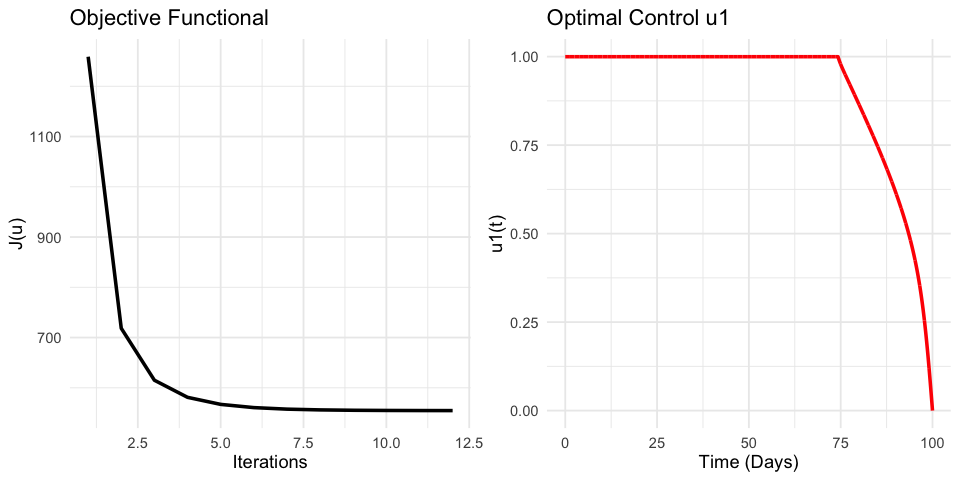

  PASS: plot_ode_results 


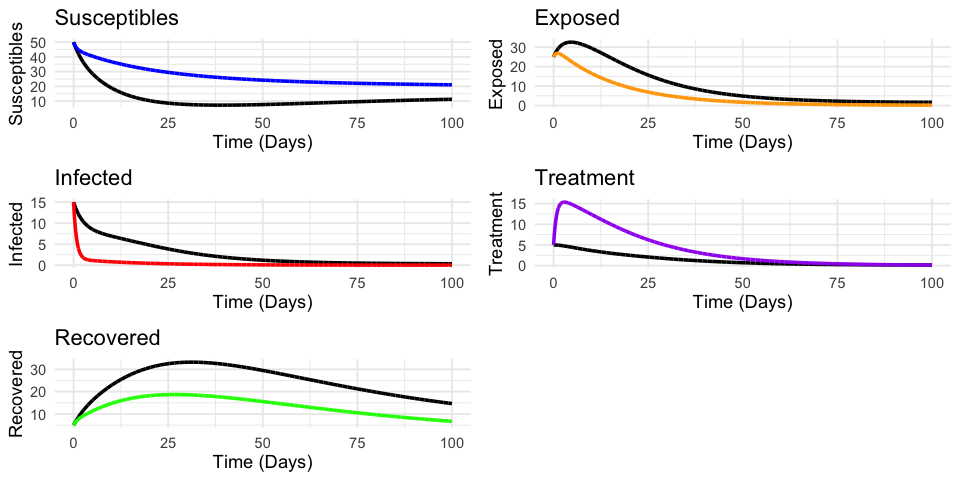

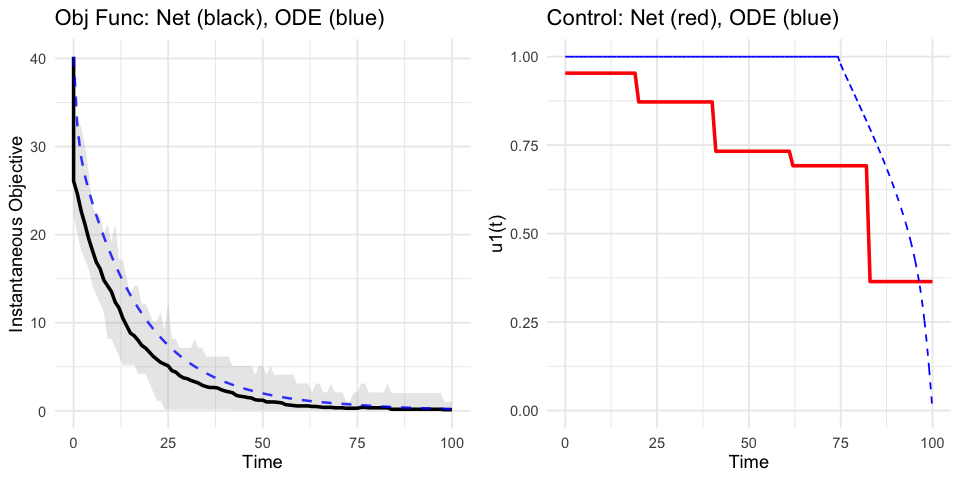

Optimizer-reported J: 404.0674 
Forward check J:     423.9169 
No-control J:        960.6135 
  PASS: plot_experiment_diagnostics 


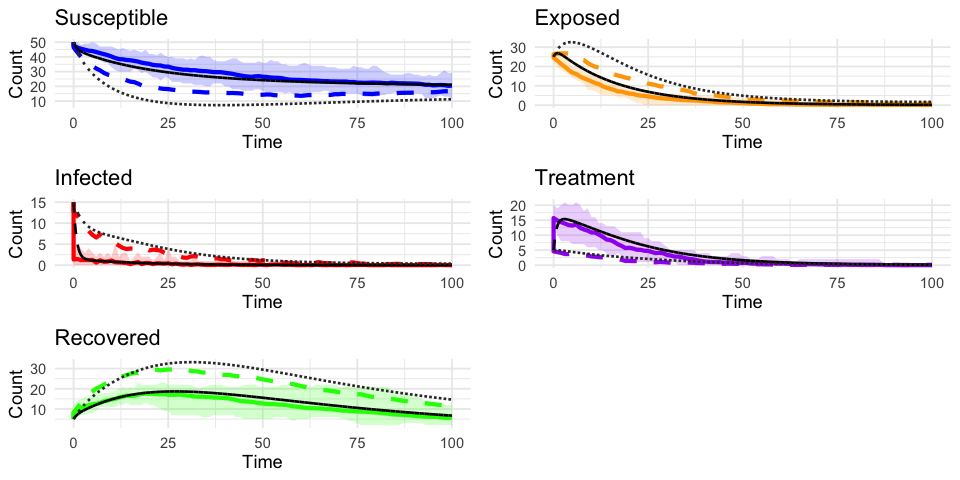

In [17]:
dsection('TEST 19: PLOTTING')
tryCatch({ plot_ode_results(ode_sol); PASS('plot_ode_results') },
  error = function(e) FAIL('plot_ode_results', e$message))
if (!is.null(opt_result)) {
  tryCatch({ plot_experiment_diagnostics(opt_result, ode_sol, w1); PASS('plot_experiment_diagnostics') },
    error = function(e) FAIL('plot_experiment_diagnostics', e$message))
}
if (is.null(opt_result)) WARN('plot_experiment_diagnostics', 'skipped')
flush_diag()

# 20 — Size Scaling: n=50 and n=200

In [18]:
dsection('TEST 20: SIZE SCALING')
for (n_test in c(50, 200)) {
  sf <- n_test / 100
  iS <- round(50*sf); iE <- round(25*sf); iI <- round(15*sf)
  iT <- round(5*sf); iR <- round(5*sf)
  dlog('Testing n=', n_test, '...')
  for (net in c('ER','BA','WS')) {
    par1 <- if (net=='WS') 0.3 else if (net=='BA') 0.05 else 0.5
    par2 <- if (net=='WS') 4L else 10L
    res <- tryCatch(
      run_seitr_simulation_cpp(net, n_test, par1, par2,
        Lambda,beta1,beta2,beta3,alpha1,alpha2,delta_I,delta_T,mu,
        iS,iE,iI,iT,iR,t_max,rep(0.03,t_max+1),3L,w1),
      error = function(e) { FAIL(sprintf('%s n=%d', net, n_test), e$message); NULL })
    if (is.null(res)) next
    ok <- nrow(res$avg)==t_max+2 && all(res$avg$N >= 0)
    if (ok) PASS(sprintf('%s n=%d', net, n_test), sprintf('final_N=%.0f', tail(res$avg$N,1)))
    if (!ok) FAIL(sprintf('%s n=%d output', net, n_test))
  }
}
flush_diag()


  TEST 20: SIZE SCALING
[04:43:02] Testing n=50... 
  PASS: ER n=50 -- final_N=22 
  PASS: BA n=50 -- final_N=25 
  PASS: WS n=50 -- final_N=26 
[04:43:02] Testing n=200... 
  PASS: ER n=200 -- final_N=36 
  PASS: BA n=200 -- final_N=38 
  PASS: WS n=200 -- final_N=46 


# 21 — Edge Cases

In [19]:
dsection('TEST 21: EDGE CASES')

# Zero control
res_z <- run_seitr_simulation_cpp('ER',100,0.5,10L,Lambda,beta1,beta2,beta3,
  alpha1,alpha2,delta_I,delta_T,mu,init_S,init_E,init_I,init_T,init_R,
  t_max,rep(0,total_steps),3L,w1)
if (all(res_z$avg$control_cost==0)) PASS('Zero control: cost = 0')
if (!all(res_z$avg$control_cost==0)) FAIL('Zero control: cost should be 0')

# Max control
res_m <- run_seitr_simulation_cpp('ER',100,0.5,10L,Lambda,beta1,beta2,beta3,
  alpha1,alpha2,delta_I,delta_T,mu,init_S,init_E,init_I,init_T,init_R,
  t_max,rep(zeta,total_steps),3L,w1)
if (all(res_m$avg$control_cost > 0)) PASS('Max control: cost > 0')
if (!all(res_m$avg$control_cost > 0)) FAIL('Max control: cost should be > 0')

# K=1
u_k1 <- expand_u1(0.5, total_steps, total_steps, zeta)
k1_ok <- length(u_k1)==total_steps && all(u_k1==0.5)
if (k1_ok) PASS('K=1 expansion', 'uniform 0.5')
if (!k1_ok) FAIL('K=1 expansion')

# K = total_steps
segs_fine <- runif(total_steps, 0, zeta)
u_fine <- expand_u1(segs_fine, total_steps, 1, zeta)
fine_ok <- length(u_fine)==total_steps && max(abs(u_fine - pmin(zeta, pmax(0, segs_fine))))<1e-10
if (fine_ok) PASS('K=total_steps expansion')
if (!fine_ok) FAIL('K=total_steps expansion')

# Very sparse
res_sp <- tryCatch(
  run_seitr_simulation_cpp('ER',100,0.01,10L,Lambda,beta1,beta2,beta3,
    alpha1,alpha2,delta_I,delta_T,mu,init_S,init_E,init_I,init_T,init_R,
    t_max,rep(0.03,total_steps),3L,w1),
  error = function(e) { FAIL('Sparse ER p=0.01', e$message); NULL })
if (!is.null(res_sp)) PASS('Sparse ER p=0.01 runs', sprintf('final_N=%.0f', tail(res_sp$avg$N,1)))

# Very dense
res_dn <- tryCatch(
  run_seitr_simulation_cpp('ER',100,0.99,10L,Lambda,beta1,beta2,beta3,
    alpha1,alpha2,delta_I,delta_T,mu,init_S,init_E,init_I,init_T,init_R,
    t_max,rep(0.03,total_steps),3L,w1),
  error = function(e) { FAIL('Dense ER p=0.99', e$message); NULL })
if (!is.null(res_dn)) PASS('Dense ER p=0.99 runs', sprintf('final_N=%.0f', tail(res_dn$avg$N,1)))
flush_diag()


  TEST 21: EDGE CASES
  PASS: Zero control: cost = 0 
  PASS: Max control: cost > 0 
  PASS: K=1 expansion -- uniform 0.5 
  PASS: K=total_steps expansion 
  PASS: Sparse ER p=0.01 runs -- final_N=29 
  PASS: Dense ER p=0.99 runs -- final_N=29 


# 22 — Diagnosis Summary

In [20]:
dsection('DIAGNOSIS SUMMARY')
dlog('')
dlog(sprintf('  PASSED:   %d', n_pass))
dlog(sprintf('  FAILED:   %d', n_fail))
dlog(sprintf('  WARNINGS: %d', n_warn))
dlog(sprintf('  TOTAL:    %d', n_pass + n_fail + n_warn))
dlog('')
if (n_fail == 0) {
  dlog('*** ALL TESTS PASSED -- experiment pipeline is ready. ***')
  cat('\n=== ALL TESTS PASSED ===\n\n')
}
if (n_fail > 0) {
  dlog(sprintf('*** %d TEST(S) FAILED -- resolve before running ch3_analysis.ipynb ***', n_fail))
  cat(sprintf('\n=== %d FAILURE(S) DETECTED -- see diagnosis.log ===\n\n', n_fail))
}
if (n_warn > 0) dlog(sprintf('  %d warning(s) -- review for stochastic variability.', n_warn))
flush_diag()
cat('Full log written to: diagnosis.log\n')


  DIAGNOSIS SUMMARY
[04:43:02]  
[04:43:02]   PASSED:   133 
[04:43:02]   FAILED:   0 
[04:43:02]   WARNINGS: 2 
[04:43:02]   TOTAL:    135 
[04:43:02]  
[04:43:02] *** ALL TESTS PASSED -- experiment pipeline is ready. *** 

=== ALL TESTS PASSED ===

[04:43:02]   2 warning(s) -- review for stochastic variability. 
Full log written to: diagnosis.log
